# Acesso a APIs Públicas com Python


## Importando as bibliotecas necessárias

In [1]:
import requests
import json
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import time  # Adicionando biblioteca para controle de tempo entre requisições


In [2]:
# Configurando o pandas para exibir todas as colunas
pd.set_option('display.max_columns', None)

## Introdução às APIs Públicas

## O que são APIs Públicas?
### APIs (Application Programming Interfaces) são conjuntos de regras e protocolos que permitem que diferentes aplicações se comuniquem entre si.
### Existem diferentes tipos de APIs, mas as mais comuns são:   
### APIs <strong>públicas</strong> são interfaces disponibilizadas por empresas, governos ou organizações para acesso externo aos seus dados e serviços.
### Vantagens do uso de APIs:
####
    <li>Acesso a dados atualizados e confiáveis</li>
    <li>Economia de recursos (não precisa criar e manter bases de dados próprias)</li>
    <li>Integração com serviços especializados</li>
    <li>Automatização de processos de coleta de dados</li>
</ul>



## Função auxiliar para fazer requisições com tratamento de erros

In [6]:
def fazer_requisicao(url, params=None, headers=None, timeout=10):
    """
    Função para fazer requisições HTTP com tratamento de erros
    
    Args:
        url (str): URL para a requisição
        params (dict, optional): Parâmetros para a requisição
        headers (dict, optional): Cabeçalhos para a requisição
        timeout (int, optional): Tempo limite em segundos
        
    Returns:
        dict: Resposta da requisição em formato JSON ou None em caso de erro
    """
    try:
        # Definindo cabeçalhos padrão se não forem fornecidos
        if headers is None:
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
            }
        
        # Fazendo a requisição
        response = requests.get(url, params=params, headers=headers, timeout=timeout)
        
        # Verificando o status da resposta
        if response.status_code == 200:
            # Tentando converter para JSON
            try:
                return response.json()
            except json.JSONDecodeError:
                # Se não for JSON, retorna o conteúdo como texto
                return response.text
        else:
            print(f"Erro na requisição: Status code {response.status_code}")
            return None
    
    except requests.exceptions.Timeout:
        print(f"Erro: Tempo limite excedido ao acessar {url}")
        return None
    except requests.exceptions.ConnectionError:
        print(f"Erro: Problema de conexão ao acessar {url}")
        return None
    except Exception as e:
        print(f"Erro inesperado: {str(e)}")
        return None


### EXemplo CEP

In [8]:

# Exemplo 1: API de CEP (ViaCEP)
print("Exemplo 1: Consultando CEP via API ViaCEP")

# CEP da Praça da Sé em São Paulo
cep = "01001000"  
url_cep = f'https://viacep.com.br/ws/{cep}/json/'

# Fazendo a requisição usando nossa função auxiliar
dados_cep = fazer_requisicao(url_cep)
dados_cep

Exemplo 1: Consultando CEP via API ViaCEP


{'cep': '01001-000',
 'logradouro': 'Praça da Sé',
 'complemento': 'lado ímpar',
 'unidade': '',
 'bairro': 'Sé',
 'localidade': 'São Paulo',
 'uf': 'SP',
 'estado': 'São Paulo',
 'regiao': 'Sudeste',
 'ibge': '3550308',
 'gia': '1004',
 'ddd': '11',
 'siafi': '7107'}

In [10]:
  # Formatando a saída JSON para melhor visualização
print(json.dumps(dados_cep, indent=4, ensure_ascii=False))

{
    "cep": "01001-000",
    "logradouro": "Praça da Sé",
    "complemento": "lado ímpar",
    "unidade": "",
    "bairro": "Sé",
    "localidade": "São Paulo",
    "uf": "SP",
    "estado": "São Paulo",
    "regiao": "Sudeste",
    "ibge": "3550308",
    "gia": "1004",
    "ddd": "11",
    "siafi": "7107"
}


In [11]:
if dados_cep:
    # Criando um DataFrame com os dados para melhor visualização
    df_cep = pd.DataFrame([dados_cep])
    print("\nDataFrame com os dados do CEP:")
    display(df_cep)
    
    # Criando um mapa simples com o endereço (opcional)
    try:
        # Construindo o endereço completo
        endereco = f"{dados_cep['logradouro']}, {dados_cep['bairro']}, {dados_cep['localidade']}, {dados_cep['uf']}"
        print(f"\nEndereço completo: {endereco}")
        
        # Aqui poderia ser adicionado código para exibir um mapa usando bibliotecas como folium
        # Exemplo: folium.Map(location=[latitude, longitude], zoom_start=15)
    except KeyError:
        print("Não foi possível construir o endereço completo.")




DataFrame com os dados do CEP:


,cep,logradouro,complemento,unidade,bairro,localidade,uf,estado,regiao,ibge,gia,ddd,siafi
0,01001-000,Praça da Sé,lado ímpar,,Sé,São Paulo,SP,São Paulo,Sudeste,3550308,1004,11,7107



Endereço completo: Praça da Sé, Sé, São Paulo, SP


### Exemplo 2: API de cotações de moedas

In [17]:
# Definindo as moedas que queremos consultar
moedas = "USD-BRL,EUR-BRL,BTC-BRL"
url_cotacoes = f'https://economia.awesomeapi.com.br/last/{moedas}'

# Fazendo a requisição
cotacoes = fazer_requisicao(url_cotacoes)
print("\nCotações atuais:")
rint(json.dumps(cotacoes, indent=4, ensure_ascii=False))


Cotações atuais:
{
    "USDBRL": {
        "code": "USD",
        "codein": "BRL",
        "name": "Dólar Americano/Real Brasileiro",
        "high": "5.7324",
        "low": "5.6376",
        "varBid": "-0.02459",
        "pctChange": "-0.433046",
        "bid": "5.6538",
        "ask": "5.6568",
        "timestamp": "1745875454",
        "create_date": "2025-04-28 18:24:14"
    },
    "EURBRL": {
        "code": "EUR",
        "codein": "BRL",
        "name": "Euro/Real Brasileiro",
        "high": "6.50195",
        "low": "6.41026",
        "varBid": "0.008313",
        "pctChange": "0.129021",
        "bid": "6.45161",
        "ask": "6.46831",
        "timestamp": "1745875448",
        "create_date": "2025-04-28 18:24:08"
    },
    "BTCBRL": {
        "code": "BTC",
        "codein": "BRL",
        "name": "Bitcoin/Real Brasileiro",
        "high": "545888",
        "low": "531738",
        "varBid": "-4737",
        "pctChange": "-0.877",
        "bid": "535615",
        "ask"


DataFrame com as cotações:


,Moeda,Valor,Variação,Máxima,Mínima,Data/Hora
0,Dólar,5.65380,-0.024590,5.73240,5.63760,2025-04-28 18:24:14
1,Euro,6.45161,0.008313,6.50195,6.41026,2025-04-28 18:24:08
2,Bitcoin,535615.00000,-4737.000000,545888.00000,531738.00000,2025-04-28 18:25:28


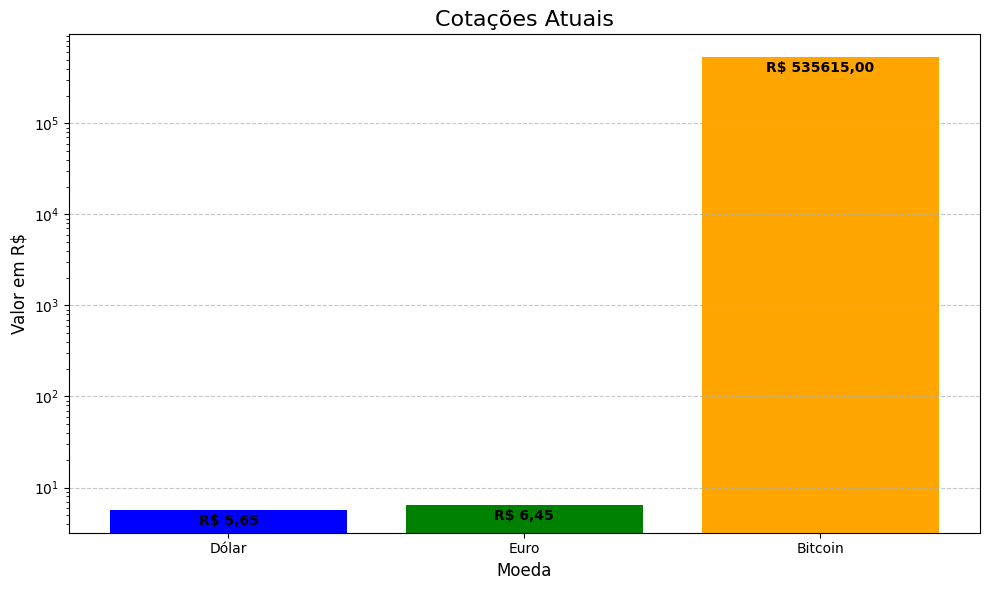

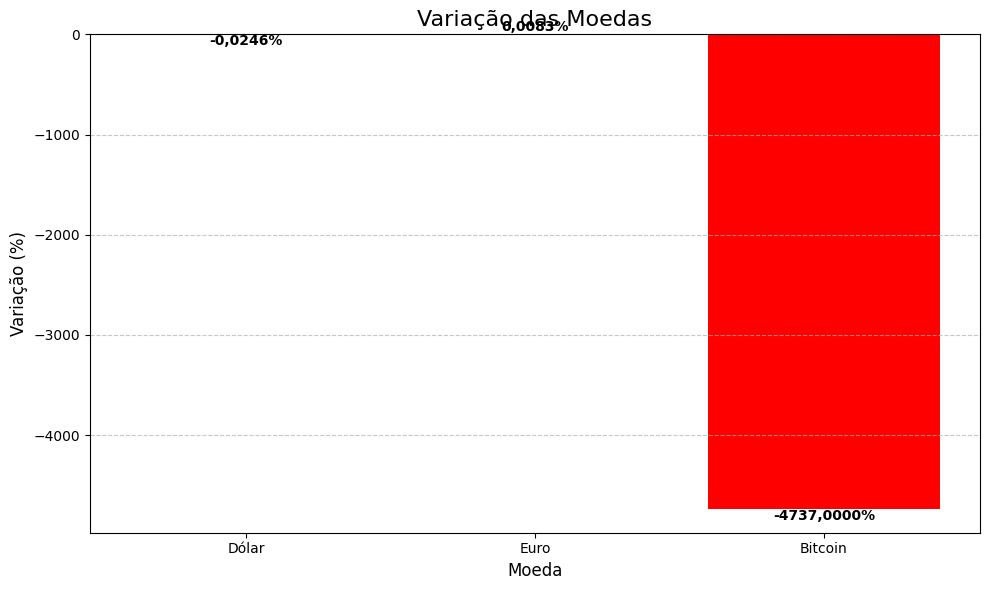

In [18]:



if cotacoes:
    try:
        # Criando um DataFrame com as cotações para melhor visualização
        df_cotacoes = pd.DataFrame([
            {
                'Moeda': 'Dólar',
                'Valor': float(cotacoes['USDBRL']['bid']),
                'Variação': float(cotacoes['USDBRL']['varBid']),
                'Máxima': float(cotacoes['USDBRL']['high']),
                'Mínima': float(cotacoes['USDBRL']['low']),
                'Data/Hora': cotacoes['USDBRL']['create_date']
            },
            {
                'Moeda': 'Euro',
                'Valor': float(cotacoes['EURBRL']['bid']),
                'Variação': float(cotacoes['EURBRL']['varBid']),
                'Máxima': float(cotacoes['EURBRL']['high']),
                'Mínima': float(cotacoes['EURBRL']['low']),
                'Data/Hora': cotacoes['EURBRL']['create_date']
            },
            {
                'Moeda': 'Bitcoin',
                'Valor': float(cotacoes['BTCBRL']['bid']),
                'Variação': float(cotacoes['BTCBRL']['varBid']),
                'Máxima': float(cotacoes['BTCBRL']['high']),
                'Mínima': float(cotacoes['BTCBRL']['low']),
                'Data/Hora': cotacoes['BTCBRL']['create_date']
            }
        ])
        
        print("\nDataFrame com as cotações:")
        display(df_cotacoes)
        
        # Criando um gráfico de barras com as cotações
        plt.figure(figsize=(10, 6))
        barras = plt.bar(df_cotacoes['Moeda'], df_cotacoes['Valor'], 
                 color=['blue', 'green', 'orange'])
        
        # Configurando o gráfico
        plt.title('Cotações Atuais', fontsize=16)
        plt.xlabel('Moeda', fontsize=12)
        plt.ylabel('Valor em R$', fontsize=12)
        plt.yscale('log')  # Escala logarítmica para visualizar melhor (Bitcoin tem valor muito maior)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Adicionando os valores nas barras
        for i, barra in enumerate(barras):
            valor = df_cotacoes['Valor'].iloc[i]
            if valor > 1000:
                texto = f'R$ {valor:.2f}'.replace('.', ',')
            else:
                texto = f'R$ {valor:.2f}'.replace('.', ',')
            plt.text(i, valor * 0.9, texto, ha='center', va='top', fontweight='bold')
            
        plt.tight_layout()  # Ajusta automaticamente o layout
        plt.show()
        
        # Gráfico adicional: Variação das moedas
        plt.figure(figsize=(10, 6))
        cores = ['green' if var >= 0 else 'red' for var in df_cotacoes['Variação']]
        plt.bar(df_cotacoes['Moeda'], df_cotacoes['Variação'], color=cores)
        plt.title('Variação das Moedas', fontsize=16)
        plt.xlabel('Moeda', fontsize=12)
        plt.ylabel('Variação (%)', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Adicionando os valores nas barras
        for i, valor in enumerate(df_cotacoes['Variação']):
            plt.text(i, valor + (0.001 if valor >= 0 else -0.001), 
                    f'{valor:.4f}%'.replace('.', ','), 
                    ha='center', va='bottom' if valor >= 0 else 'top', 
                    fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
    except KeyError as e:
        print(f"Erro ao processar dados de cotações: Chave não encontrada - {e}")
    except Exception as e:
        print(f"Erro ao processar dados de cotações: {e}")


3: Extraindo dados de uma página web com BeautifulSoup

In [19]:


# URL de exemplo - página da Wikipedia sobre Python
url_wiki = "https://pt.wikipedia.org/wiki/Python"

# Configurando cabeçalhos para simular um navegador
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    # Fazendo a requisição para a página
    response = requests.get(url_wiki, headers=headers)
    
    if response.status_code == 200:
        # Criando o objeto BeautifulSoup para analisar o HTML
        soup = BeautifulSoup(response.content, 'html.parser')
        
        # Extraindo o título da página
        titulo = soup.find('h1', id='firstHeading').text.strip()
        print(f"\nTítulo da página: {titulo}")
        
        # Extraindo o primeiro parágrafo
        primeiro_paragrafo = soup.find('div', class_='mw-parser-output').find('p', recursive=False)
        if primeiro_paragrafo:
            print(f"\nPrimeiro parágrafo: {primeiro_paragrafo.text.strip()}")
        
        # Extraindo os tópicos principais (cabeçalhos h2)
        print("\nTópicos principais:")
        for h2 in soup.find_all('h2')[:5]:  # Limitando aos primeiros 5 para não sobrecarregar
            # Removendo os elementos [editar] que aparecem nos cabeçalhos
            span = h2.find('span', class_='mw-headline')
            if span:
                print(f"- {span.text.strip()}")
        
        # Extraindo links externos
        print("\nAlguns links externos:")
        links_externos = soup.find('div', id='mw-navigation').find_all('a')[:5]
        for link in links_externos:
            href = link.get('href', '')
            texto = link.text.strip()
            if texto and href:
                print(f"- {texto}: {href}")
        
        # Extraindo a primeira imagem
        primeira_imagem = soup.find('img')
        if primeira_imagem:
            src = primeira_imagem.get('src', '')
            alt = primeira_imagem.get('alt', 'Sem descrição')
            print(f"\nPrimeira imagem: {alt}")
            print(f"URL da imagem: {src if src.startswith('http') else 'https:' + src}")
    else:
        print(f"Erro ao acessar a página: {response.status_code}")
        
except Exception as e:
    print(f"Erro ao processar a página: {e}")




Título da página: Python

Primeiro parágrafo: Python é uma linguagem de programação de alto nível,[10] interpretada de script, imperativa, orientada a objetos, funcional, de tipagem dinâmica e forte. Foi lançada por Guido van Rossum em 1991.[1] Atualmente, possui um modelo de desenvolvimento comunitário, aberto e gerenciado pela organização sem fins lucrativos Python Software Foundation. Apesar de várias partes da linguagem possuírem padrões e especificações formais, a linguagem, como um todo, não é formalmente especificada. O padrão na pratica é a implementação CPython.

Tópicos principais:

Alguns links externos:

Primeira imagem: 
URL da imagem: https:/static/images/icons/wikipedia.png


###  Extraindo dados estruturados de uma página web

In [21]:
# URL de exemplo - página com tabela de dados
url_tabela = "https://www.worldometers.info/coronavirus/"

try:
    # Fazendo a requisição para a página
    response = requests.get(url_tabela, headers=headers)
    
    if response.status_code == 200:
        # Criando o objeto BeautifulSoup
        soup = BeautifulSoup(response.content, 'html.parser')
        
        # Encontrando a tabela principal
        tabela = soup.find('table', id='main_table_countries_today')
        
        if tabela:
            # Extraindo os cabeçalhos da tabela
            cabecalhos = []
            for th in tabela.find('thead').find_all('th'):
                cabecalhos.append(th.text.strip())
            
            print("\nCabeçalhos da tabela:")
            print(cabecalhos[:5])  # Mostrando apenas os primeiros 5 cabeçalhos
            
            # Extraindo os dados dos primeiros 5 países
            dados_paises = []
            for tr in tabela.find('tbody').find_all('tr')[:5]:
                pais = {}
                for i, td in enumerate(tr.find_all('td')):
                    if i < len(cabecalhos):
                        pais[cabecalhos[i]] = td.text.strip()
                if pais:
                    dados_paises.append(pais)
            
            # Criando um DataFrame com os dados
            if dados_paises:
                df_paises = pd.DataFrame(dados_paises)
                print("\nDados dos primeiros 5 países:")
                display(df_paises)
        else:
            print("Tabela não encontrada na página.")
    else:
        print(f"Erro ao acessar a página: {response.status_code}")
        
except Exception as e:
    print(f"Erro ao processar a página: {e}")




Cabeçalhos da tabela:
['#', 'Country,Other', 'TotalCases', 'NewCases', 'TotalDeaths']

Dados dos primeiros 5 países:


,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/\n1M pop,Population,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop
0,,North America,"131,889,132",,"1,695,941",,"127,665,129",+350,"2,528,062","6,095",,,,,,North America,,,,,,
1,,Asia,"221,500,265",,"1,553,662",,"205,673,091",,"14,273,512","14,733",,,,,,Asia,,,,,,
2,,Europe,"253,406,198",,"2,101,824",,"248,754,104",+474,"2,550,270","4,453",,,,,,Europe,,,,,,
3,,South America,"70,200,879",,"1,367,332",,"66,683,585",,"2,149,962","8,953",,,,,,South America,,,,,,
4,,Oceania,"14,895,771",,"33,015",,"14,752,388",,"110,368",31,,,,,,Australia/Oceania,,,,,,


### 5: Acessando uma API que requer autenticação (exemplo com GitHub)

In [22]:

# URL da API do GitHub para buscar informações de um usuário
username = "microsoft"  # Exemplo com um usuário popular
url_github = f"https://api.github.com/users/{username}"

# Fazendo a requisição
dados_github = fazer_requisicao(url_github)

if dados_github:
    print(f"\nDados do usuário {username} no GitHub:")
    
    # Extraindo informações relevantes
    info_usuario = {
        "Nome": dados_github.get("name"),
        "Empresa": dados_github.get("company"),
        "Localização": dados_github.get("location"),
        "Repositórios públicos": dados_github.get("public_repos"),
        "Seguidores": dados_github.get("followers"),
        "Seguindo": dados_github.get("following"),
        "Criado em": dados_github.get("created_at")
    }
    
    # Exibindo as informações
    for chave, valor in info_usuario.items():
        print(f"{chave}: {valor}")
    
    # Buscando os repositórios mais populares do usuário
    print(f"\nRepositórios mais populares de {username}:")
    
    # URL para buscar os repositórios do usuário, ordenados por estrelas
    url_repos = f"https://api.github.com/users/{username}/repos?sort=stars&per_page=5"
    
    # Fazendo a requisição com um pequeno atraso para evitar rate limiting
    time.sleep(1)
    repos = fazer_requisicao(url_repos)
    
    if repos:
        # Criando uma lista para armazenar os dados dos repositórios
        dados_repos = []
        
        for repo in repos:
            dados_repos.append({
                "Nome": repo.get("name"),
                "Descrição": repo.get("description", "")[:50] + "..." if repo.get("description") and len(repo.get("description")) > 50 else repo.get("description", ""),
                "Estrelas": repo.get("stargazers_count"),
                "Forks": repo.get("forks_count"),
                "Linguagem": repo.get("language")
            })
        
        # Criando um DataFrame com os dados
        df_repos = pd.DataFrame(dados_repos)
        display(df_repos)
        


Dados do usuário microsoft no GitHub:
Nome: Microsoft
Empresa: None
Localização: Redmond, WA
Repositórios públicos: 6781
Seguidores: 90572
Seguindo: 0
Criado em: 2013-12-10T19:06:48Z

Repositórios mais populares de microsoft:


,Nome,Descrição,Estrelas,Forks,Linguagem
0,recipe-tool,"Experimental tool for creating ""recipes"" to dr...",2,1,Python
1,Digital-twin-builder-in-Real-Time-Intelligence,None,0,1,None
2,Build25-LAB304,Microsoft Build 2025 LAB304 - Playwright End-t...,1,0,JavaScript
3,BUILD25-LAB331,This repository hosts the instructions and wor...,0,0,Python
4,iframe-bridge,None,0,0,TypeScript


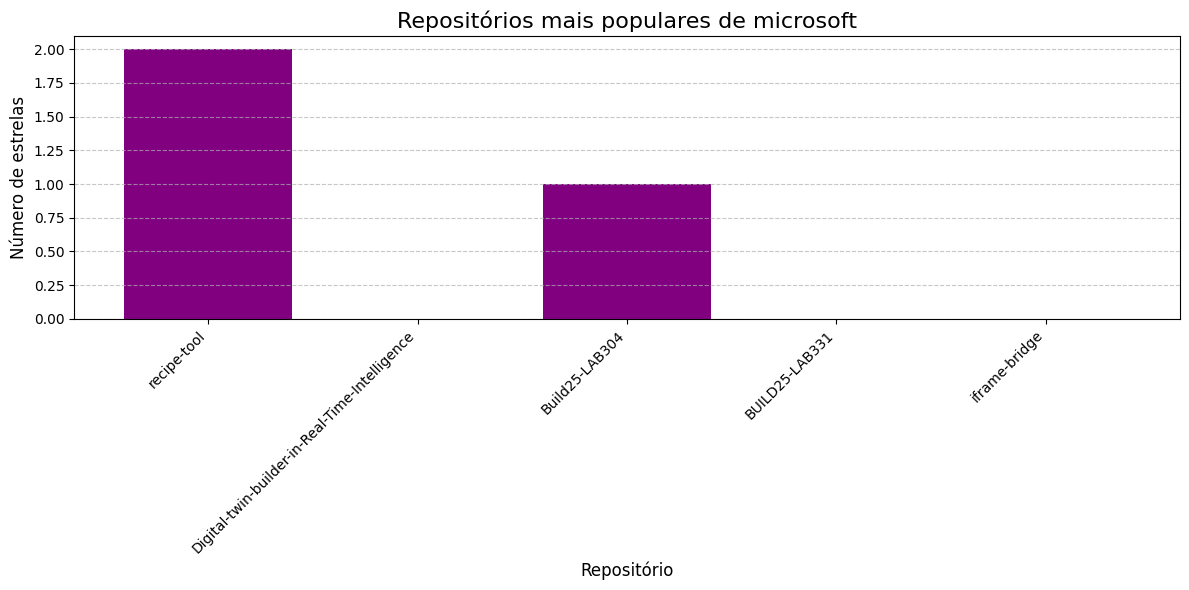

In [23]:

# Criando um gráfico de barras com as estrelas dos repositórios
plt.figure(figsize=(12, 6))
plt.bar(df_repos["Nome"], df_repos["Estrelas"], color="purple")
plt.title(f"Repositórios mais populares de {username}", fontsize=16)
plt.xlabel("Repositório", fontsize=12)
plt.ylabel("Número de estrelas", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
